# Modify RYF90-91 boundary conditions for Gregorian calendar

In [1]:
import netCDF4
import xarray as xr
import xesmf as xe
from itertools import cycle
import os
import dask
import numpy as np
import pandas as pd
import dask.array as da
import dask.bag as db
from pykdtree.kdtree import KDTree
from dask.diagnostics import ProgressBar
import subprocess
import matplotlib.pyplot as plt
from glob import glob
import cmocean.cm as cmocean

xr.set_options(keep_attrs=True) ## This ensures that performing simple operations with xarray (eg converting temperature to Celsius) preserves attributes

from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40627,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46603,Total threads: 4
Dashboard: /proxy/36817/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:38561,


In [2]:
import intake
catalog = intake.cat.access_nri
time_greg = catalog["01deg_jra55v150_iaf_cycle1"].search(variable = "temp",frequency="1day").to_dask(xarray_open_kwargs={'decode_timedelta':True}).time
time_greg


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/intake_esm/core.py:259: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
Exception ignored in: <function CachingFileManager.__del__ at 0x14ac67643380>
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File

<xarray.DataArray 'time' (time: 18231)> Size: 146kB
array(['1970-01-01T12:00:00.000000000', '1970-01-02T12:00:00.000000000',
       '1970-01-03T12:00:00.000000000', ..., '2019-12-29T12:00:00.000000000',
       '2019-12-30T12:00:00.000000000', '2019-12-31T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 146kB 1970-01-01T12:00:00 ... 2019-12-31T1...
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   GREGORIAN
    bounds:          time_bnds

In [3]:
#time_greg = time_greg.sel(time = slice('1980-01-01','1989-12-31'))

In [4]:
ds_9091 = xr.open_dataset("/g/data/x77/cy8964/mom6/input/input-8km/forcing_access_yr2_8km_fill_mod.nc", decode_times=False)
ds_9091

<xarray.Dataset> Size: 15GB
Dimensions:                  (time: 365, nz_segment_001_u: 75,
                              nz_segment_001_v: 75,
                              nz_segment_001_pot_temp: 75,
                              nz_segment_001_salt: 75, nx_segment_001: 8641,
                              ny_segment_001: 1)
Coordinates:
  * time                     (time) float64 3kB 0.0 1.0 2.0 ... 363.0 364.0
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 2GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 2GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 25MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 2GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 2GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 2GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 2GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 2GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 2GB ...
    ilist_segment_001        (ny_segment_001, nx_segment_001) float64 69kB ...
    jlist_segment_001        (ny_segment_001, nx_segment_001) float64 69kB ...
Attributes:
    regrid_method:  bilinear
    history:        Thu Nov  6 22:59:52 2025: ncatted -a axis,nx_segment_001,...
    NCO:            netCDF Operators version 5.0.5 (Homepage = http://nco.sf....

In [5]:
ds_9091 = ds_9091.load()

In [6]:
time_greg = time_greg.load()

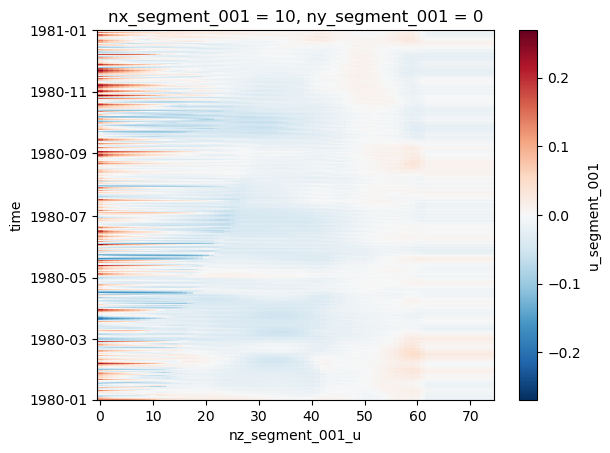

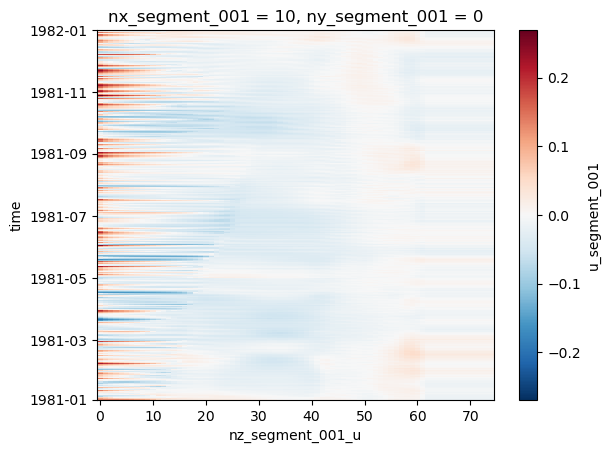

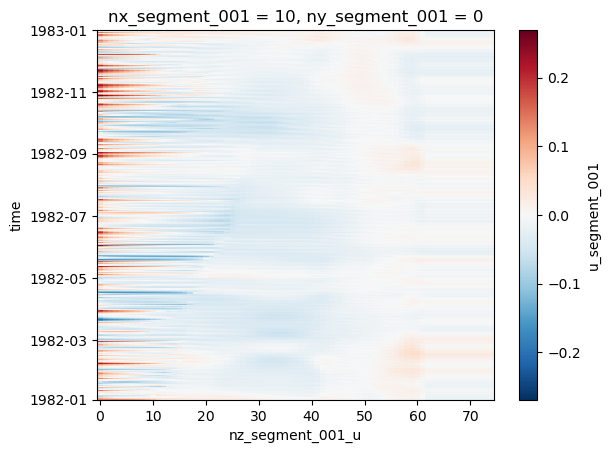

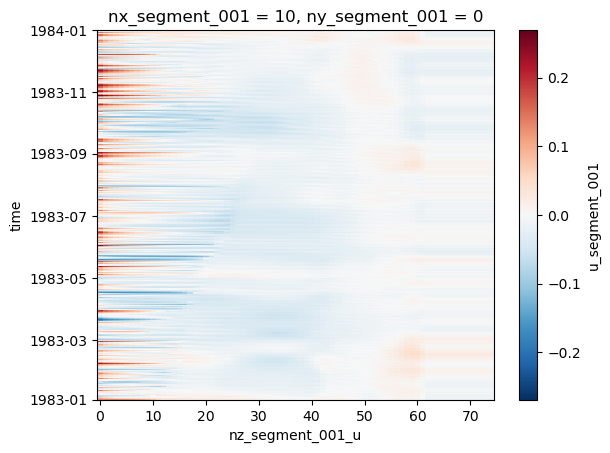

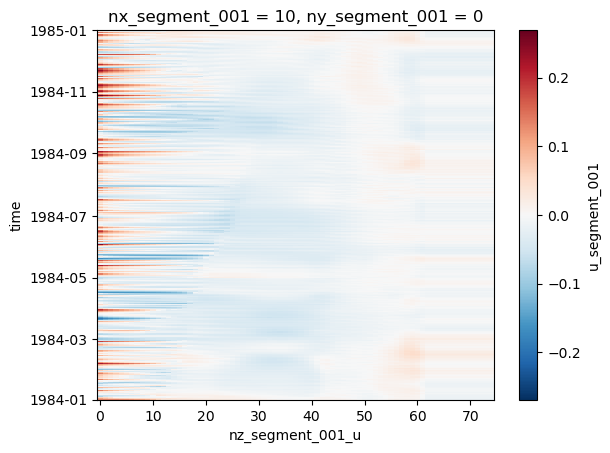

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1829, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1979-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    regrid_method:  bilinear
    history:        Thu Nov  6 22:59:52 2025: ncatted -a axis,nx_segment_001,...
    NCO:            netCDF Operators version 5.0.5 (Homepage = http://nco.sf....

In [12]:
#first make a leap year version of data
ds_9091_LEAP = ds_9091.copy()
ds_9091_LEAP = ds_9091_LEAP.reindex(time = np.append(np.append(np.arange(59),[58.5]),np.arange(59,365)),
                                   method = 'nearest')
ds_9091_LEAP = ds_9091_LEAP.load()

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('1979-12-31','1980-01-01T00:00:00.000000000'))
ds_first

#1980 is a leap year
ds_1980 = ds_9091_LEAP.copy()
ds_1980["time"] = time_greg.sel(time = slice('1980-01-01','1980-12-31'))
ds_1980.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1980 = ds_1980.load()

ds_1981 = ds_9091.copy()
ds_1981["time"] = time_greg.sel(time = slice('1981-01-01','1981-12-31'))
ds_1981.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1981 = ds_1981.load()

ds_1982 = ds_9091.copy()
ds_1982["time"] = time_greg.sel(time = slice('1982-01-01','1982-12-31'))
ds_1982.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1982 = ds_1982.load()

ds_1983 = ds_9091.copy()
ds_1983["time"] = time_greg.sel(time = slice('1983-01-01','1983-12-31'))
ds_1983.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1983 = ds_1983.load()

#1984 is a leap year
ds_1984 = ds_9091_LEAP.copy()
ds_1984["time"] = time_greg.sel(time = slice('1984-01-01','1984-12-31'))
ds_1984.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1984 = ds_1984.load()

# ds_1985 = ds_9091.copy()
# ds_1985["time"] = time_greg.sel(time = slice('1985-01-01','1985-12-31'))
# ds_1985.u_segment_001.isel(nx_segment_001 = 10).plot()
# plt.show()
# ds_1985 = ds_1985.load()

# ds_1986 = ds_9091.copy()
# ds_1986["time"] = time_greg.sel(time = slice('1986-01-01','1986-12-31'))
# ds_1986.u_segment_001.isel(nx_segment_001 = 10).plot()
# plt.show()
# ds_1986 = ds_1986.load()

# ds_1987 = ds_9091.copy()
# ds_1987["time"] = time_greg.sel(time = slice('1987-01-01','1987-12-31'))
# ds_1987.u_segment_001.isel(nx_segment_001 = 10).plot()
# plt.show()
# ds_1987 = ds_1987.load()

# #1988 is a leap year
# ds_1988 = ds_9091_LEAP.copy()
# ds_1988["time"] = time_greg.sel(time = slice('1988-01-01','1988-12-31'))
# ds_1988.u_segment_001.isel(nx_segment_001 = 10).plot()
# plt.show()
# ds_1988 = ds_1988.load()

# ds_1989 = ds_9091.copy()
# ds_1989["time"] = time_greg.sel(time = slice('1989-01-01','1989-12-31'))
# ds_1989.u_segment_001.isel(nx_segment_001 = 10).plot()
# plt.show()
# ds_1989 = ds_1989.load()

ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('1985-01-01','1985-01-02T00:00:00.000000000'))
ds_last

ds_1980s = xr.combine_by_coords([ds_first,
                                 ds_1980,ds_1981,ds_1982,ds_1983,
                      ds_1984,#ds_1985,ds_1986,ds_1987,
                      #ds_1988,ds_1989
                                ds_last])
ds_1980s

#plt.ylim(56,60)

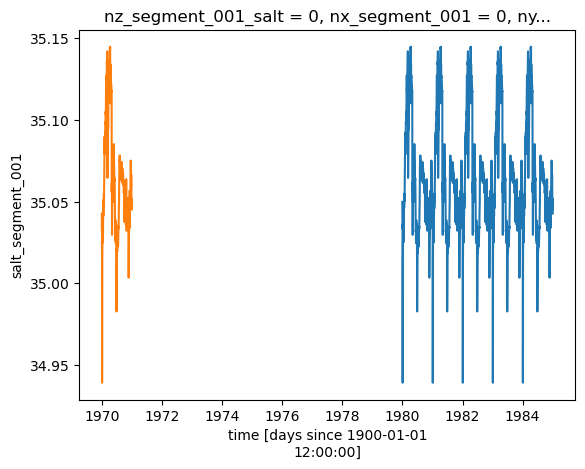

In [13]:
ds_1980s.salt_segment_001.isel(nz_segment_001_salt = 0, nx_segment_001 = 0).plot()
ds_9091.salt_segment_001.isel(nz_segment_001_salt = 0, nx_segment_001 = 0).plot()

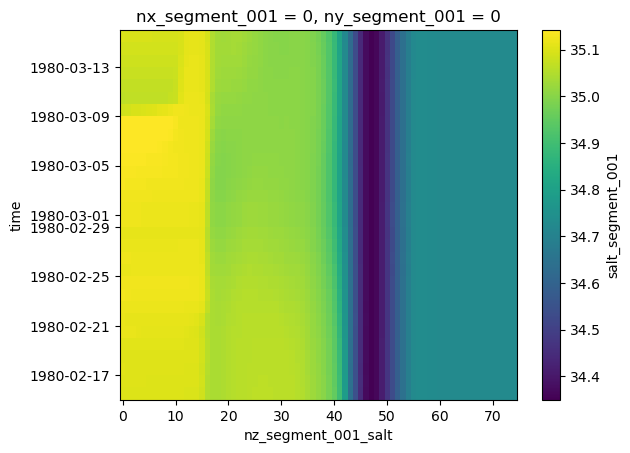

In [14]:
ds_1980s.salt_segment_001.sel(time = slice('1980-02-15','1980-03-15')).isel( nx_segment_001 = 0).plot()

In [15]:
ds_out = ds_1980s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out

#ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1980-1984_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1829, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1979-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [16]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1980-1984_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


Then do 
```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1980-1984_forcing_access_yr2_8km_fill.nc
```
to add x and y axes attributes (preventing a warning at runtime)

In [ ]:
# Make sure there are no NaN Fill_Values. Do e.g. 'ncatted -a _FillValue,dz_u_segment_001,d,,, forcing_access_yr2_005.nc' if needed.


In [18]:
ds_out

<xarray.Dataset>
Dimensions:                  (time: 365, nz_segment_001_u: 75,
                              nz_segment_001_v: 75,
                              nz_segment_001_pot_temp: 75,
                              nz_segment_001_salt: 75, nx_segment_001: 8641,
                              ny_segment_001: 1)
Coordinates:
  * time                     (time) float64 0.0 1.0 2.0 ... 362.0 363.0 364.0
  * nz_segment_001_u         (nz_segment_001_u) int32 0 1 2 3 4 ... 71 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 0 1 2 3 4 ... 71 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 0 1 2 ... 72 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 0 1 2 3 ... 71 72 73 74
  * nx_segment_001           (nx_segment_001) int32 0 1 2 3 ... 8638 8639 8640
  * ny_segment_001           (ny_segment_001) int32 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 0...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 ...
    ilist_segment_001        (ny_segment_001, nx_segment_001) float64 ...
    jlist_segment_001        (ny_segment_001, nx_segment_001) float64 ...
Attributes:
    regrid_method:  bilinear

# repeat for other time periods

In [7]:
#first make a leap year version of data
ds_9091_LEAP = ds_9091.copy()
ds_9091_LEAP = ds_9091_LEAP.reindex(time = np.append(np.append(np.arange(59),[58.5]),np.arange(59,365)),
                                   method = 'nearest')
ds_9091_LEAP = ds_9091_LEAP.load()

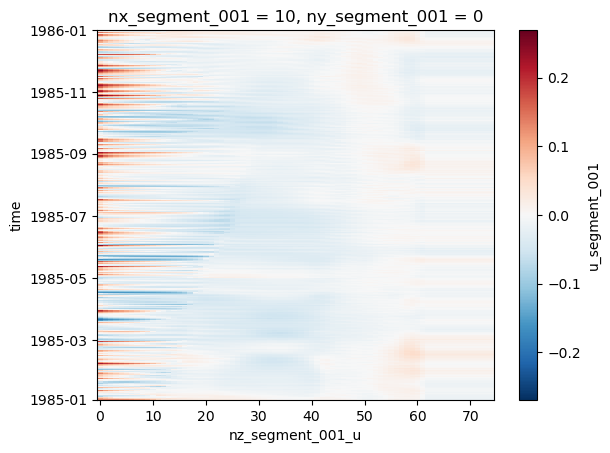

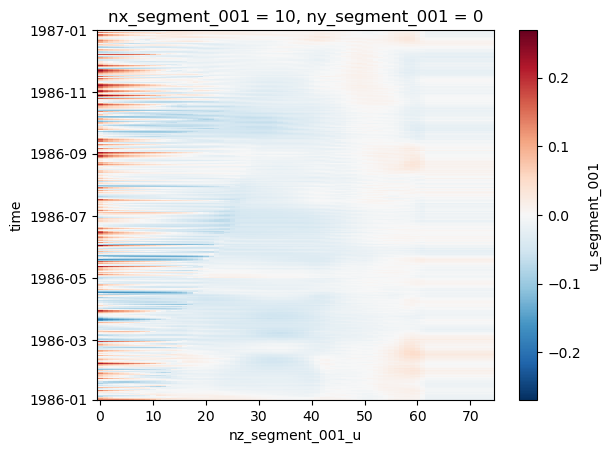

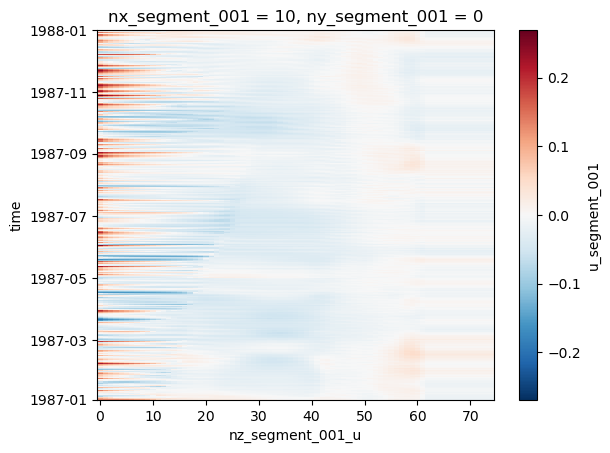

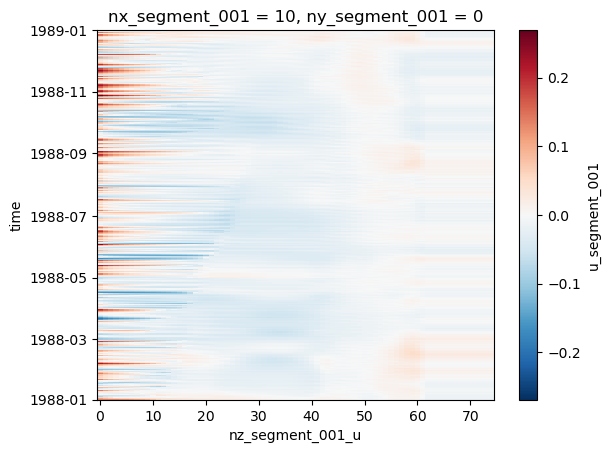

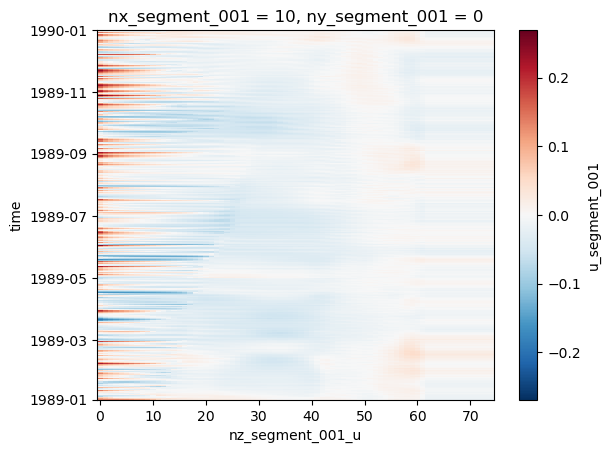

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1984-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    regrid_method:  bilinear
    history:        Thu Nov  6 22:59:52 2025: ncatted -a axis,nx_segment_001,...
    NCO:            netCDF Operators version 5.0.5 (Homepage = http://nco.sf....

In [8]:
ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('1984-12-31','1985-01-01T00:00:00.000000000'))
ds_first


ds_1985 = ds_9091.copy()
ds_1985["time"] = time_greg.sel(time = slice('1985-01-01','1985-12-31'))
ds_1985.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1985 = ds_1985.load()

ds_1986 = ds_9091.copy()
ds_1986["time"] = time_greg.sel(time = slice('1986-01-01','1986-12-31'))
ds_1986.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1986 = ds_1986.load()

ds_1987 = ds_9091.copy()
ds_1987["time"] = time_greg.sel(time = slice('1987-01-01','1987-12-31'))
ds_1987.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1987 = ds_1987.load()

#1988 is a leap year
ds_1988 = ds_9091_LEAP.copy()
ds_1988["time"] = time_greg.sel(time = slice('1988-01-01','1988-12-31'))
ds_1988.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1988 = ds_1988.load()

ds_1989 = ds_9091.copy()
ds_1989["time"] = time_greg.sel(time = slice('1989-01-01','1989-12-31'))
ds_1989.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1989 = ds_1989.load()

ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('1990-01-01','1990-01-02T00:00:00.000000000'))
ds_last

ds_1980s = xr.combine_by_coords([ds_first,
                                 #ds_1980,ds_1981,ds_1982,ds_1983,
                      #ds_1984,#
                                 ds_1985,ds_1986,ds_1987,
                      ds_1988,ds_1989,
                                ds_last])
ds_1980s

#plt.ylim(56,60)

In [10]:
ds_out = ds_1980s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1984-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [11]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1985-1989_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1985-1989_forcing_access_yr2_8km_fill.nc

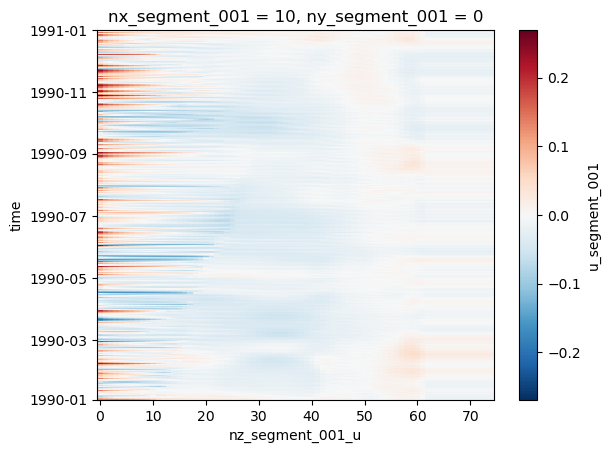

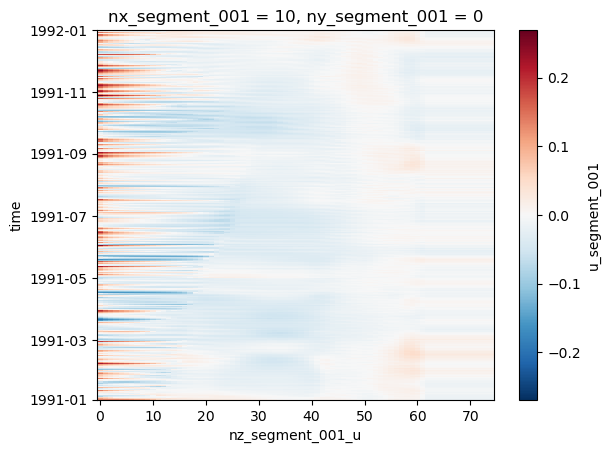

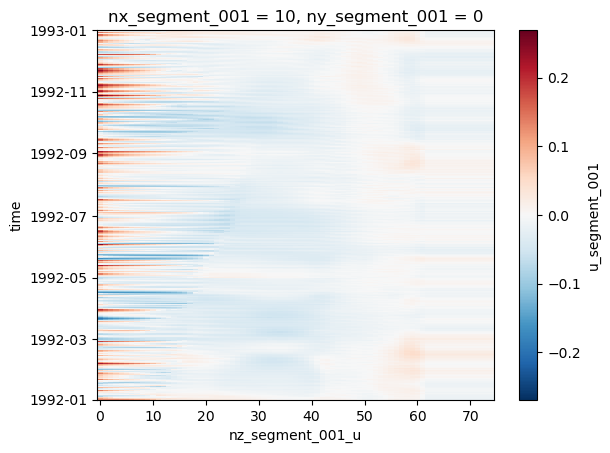

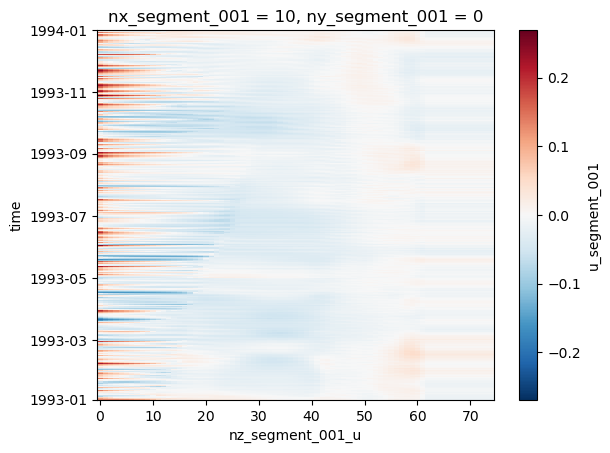

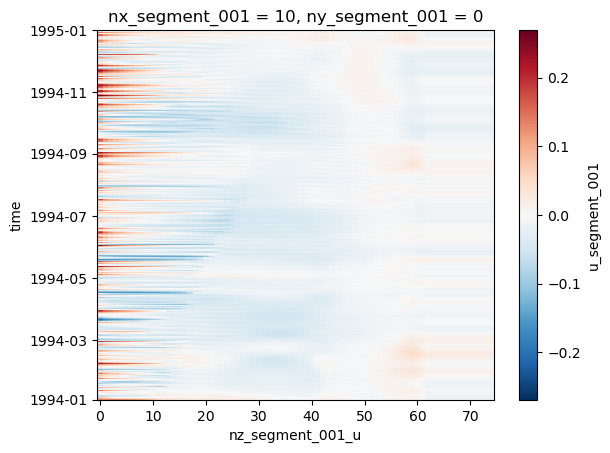

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1989-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [8]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('1989-12-31','1990-01-01T00:00:00.000000000'))
ds_first


ds_1990 = ds_9091.copy()
ds_1990["time"] = time_greg.sel(time = slice('1990-01-01','1990-12-31'))
ds_1990.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1990 = ds_1990.load()

ds_1991 = ds_9091.copy()
ds_1991["time"] = time_greg.sel(time = slice('1991-01-01','1991-12-31'))
ds_1991.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1991 = ds_1991.load()

#1992 is  a leap year
ds_1992 = ds_9091_LEAP.copy()
ds_1992["time"] = time_greg.sel(time = slice('1992-01-01','1992-12-31'))
ds_1992.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1992 = ds_1992.load()

ds_1993 = ds_9091.copy()
ds_1993["time"] = time_greg.sel(time = slice('1993-01-01','1993-12-31'))
ds_1993.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1993 = ds_1993.load()

ds_1994 = ds_9091.copy()
ds_1994["time"] = time_greg.sel(time = slice('1994-01-01','1994-12-31'))
ds_1994.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1994 = ds_1994.load()

ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('1995-01-01','1995-01-02T00:00:00.000000000'))
ds_last

ds_1990s = xr.combine_by_coords([ds_first,
                                 ds_1990, ds_1991, ds_1992, ds_1993, ds_1994,
                                ds_last])
ds_1990s

#plt.ylim(56,60)

ds_out = ds_1990s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [9]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1990-1994_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1990-1994_forcing_access_yr2_8km_fill.nc

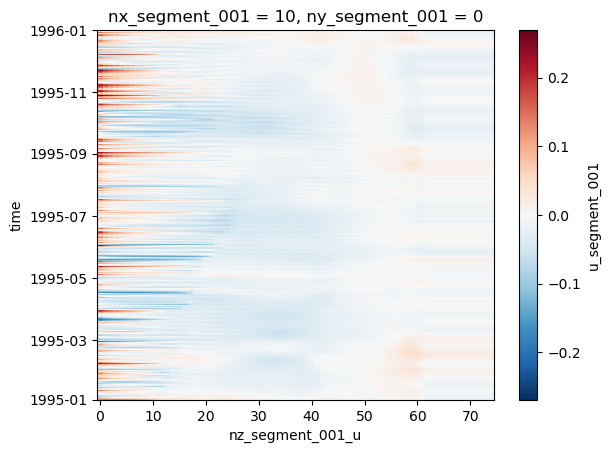

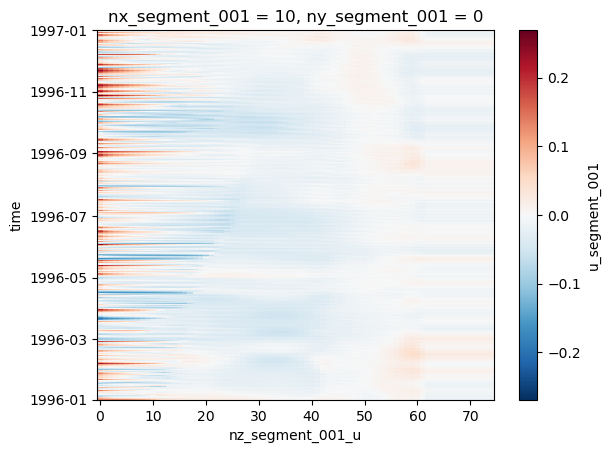

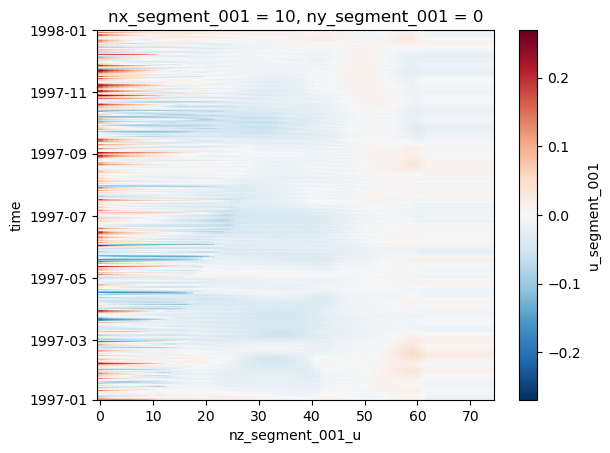

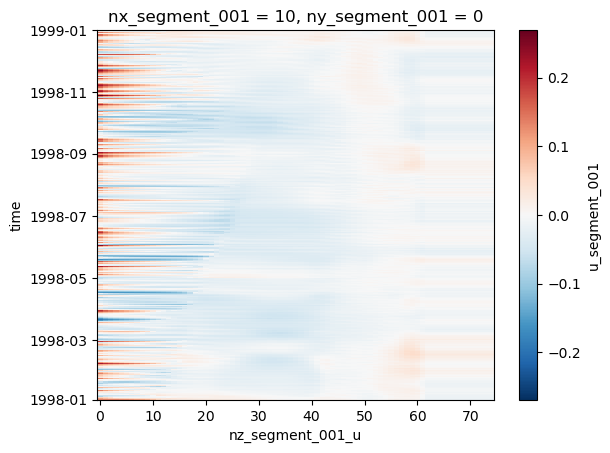

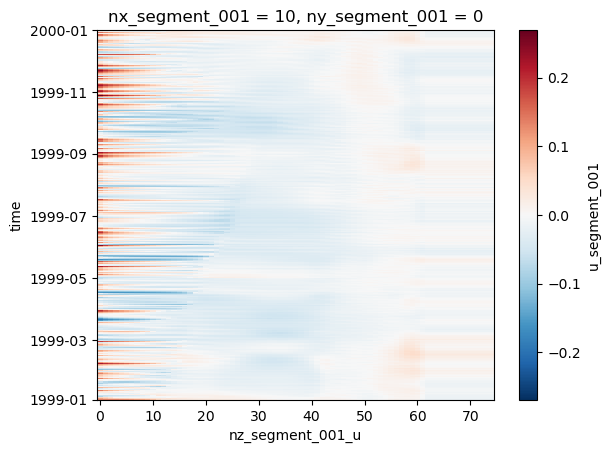

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1994-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [8]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('1994-12-31','1995-01-01T00:00:00.000000000'))
ds_first


ds_1995 = ds_9091.copy()
ds_1995["time"] = time_greg.sel(time = slice('1995-01-01','1995-12-31'))
ds_1995.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1995 = ds_1995.load()

#1996 is  a leap year
ds_1996 = ds_9091_LEAP.copy()
ds_1996["time"] = time_greg.sel(time = slice('1996-01-01','1996-12-31'))
ds_1996.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1996 = ds_1996.load()

ds_1997 = ds_9091.copy()
ds_1997["time"] = time_greg.sel(time = slice('1997-01-01','1997-12-31'))
ds_1997.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1997 = ds_1997.load()

ds_1998 = ds_9091.copy()
ds_1998["time"] = time_greg.sel(time = slice('1998-01-01','1998-12-31'))
ds_1998.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1998 = ds_1998.load()

ds_1999 = ds_9091.copy()
ds_1999["time"] = time_greg.sel(time = slice('1999-01-01','1999-12-31'))
ds_1999.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_1999 = ds_1999.load()

ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('2000-01-01','2000-01-02T00:00:00.000000000'))
ds_last

ds_1990s = xr.combine_by_coords([ds_first,
                                 ds_1995, ds_1996, ds_1997, ds_1998, ds_1999,
                                ds_last])
ds_1990s

#plt.ylim(56,60)

ds_out = ds_1990s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [9]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1995-1999_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_1995-1999_forcing_access_yr2_8km_fill.nc

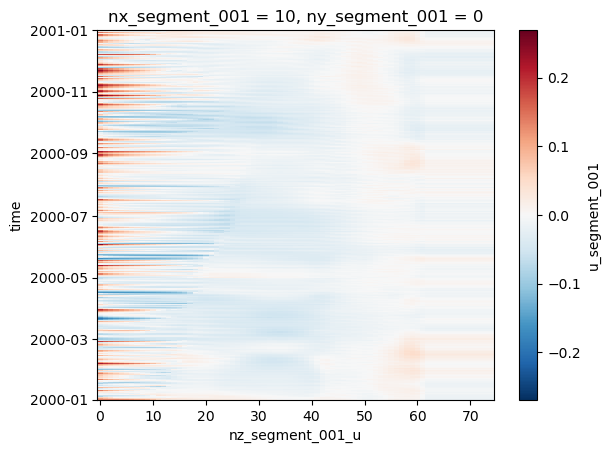

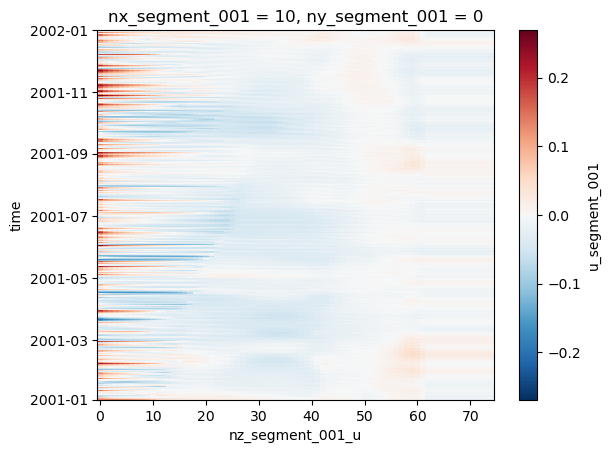

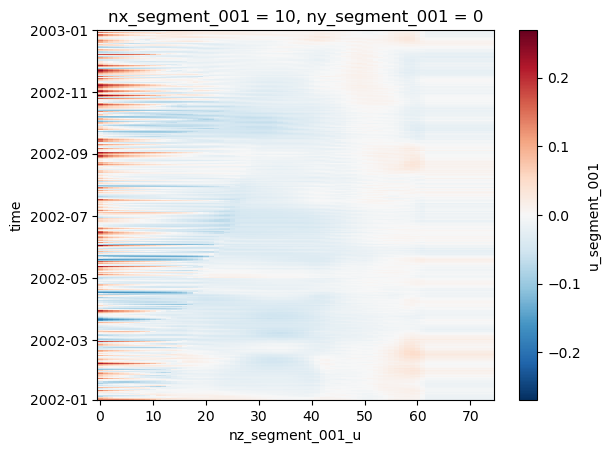

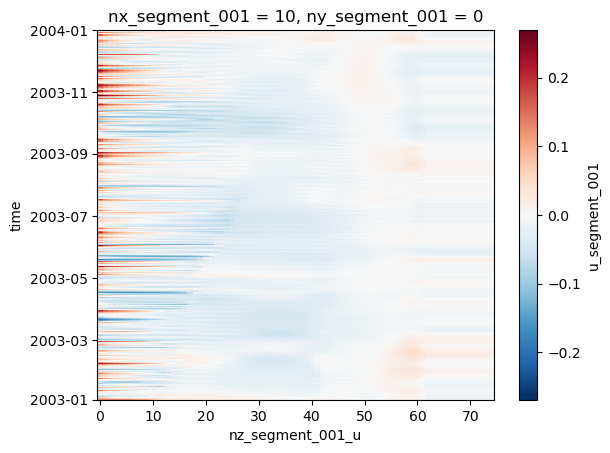

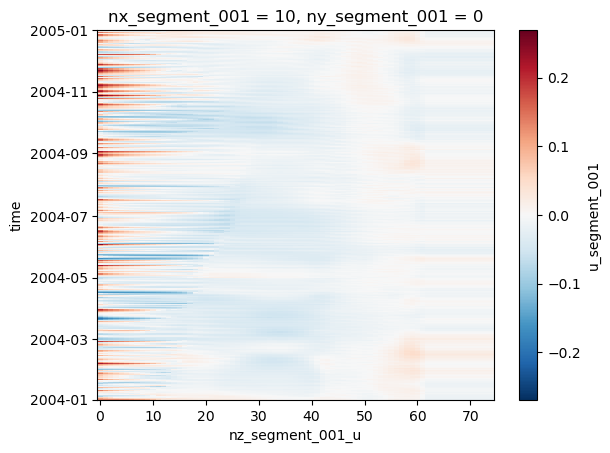

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1829, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 1999-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [9]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('1999-12-31','2000-01-01T00:00:00.000000000'))
ds_first

# 2000 is a leap year
ds_2000 = ds_9091_LEAP.copy()
ds_2000["time"] = time_greg.sel(time = slice('2000-01-01','2000-12-31'))
ds_2000.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2000 = ds_2000.load()


ds_2001 = ds_9091.copy()
ds_2001["time"] = time_greg.sel(time = slice('2001-01-01','2001-12-31'))
ds_2001.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2001 = ds_2001.load()

ds_2002 = ds_9091.copy()
ds_2002["time"] = time_greg.sel(time = slice('2002-01-01','2002-12-31'))
ds_2002.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2002 = ds_2002.load()

ds_2003 = ds_9091.copy()
ds_2003["time"] = time_greg.sel(time = slice('2003-01-01','2003-12-31'))
ds_2003.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2003 = ds_2003.load()

#2004 is  a leap year
ds_2004 = ds_9091_LEAP.copy()
ds_2004["time"] = time_greg.sel(time = slice('2004-01-01','2004-12-31'))
ds_2004.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2004 = ds_2004.load()


ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('2005-01-01','2005-01-02T00:00:00.000000000'))
ds_last

ds_2000s = xr.combine_by_coords([ds_first,
                                 ds_2000, ds_2001, ds_2002, ds_2003, ds_2004,
                                ds_last])
ds_2000s

#plt.ylim(56,60)

ds_out = ds_2000s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [10]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2000-2004_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2000-2004_forcing_access_yr2_8km_fill.nc

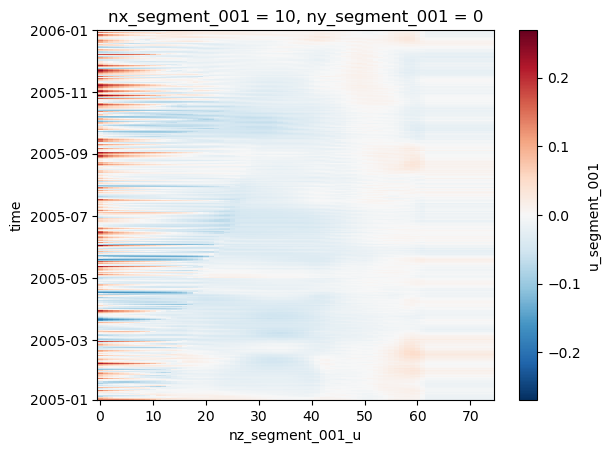

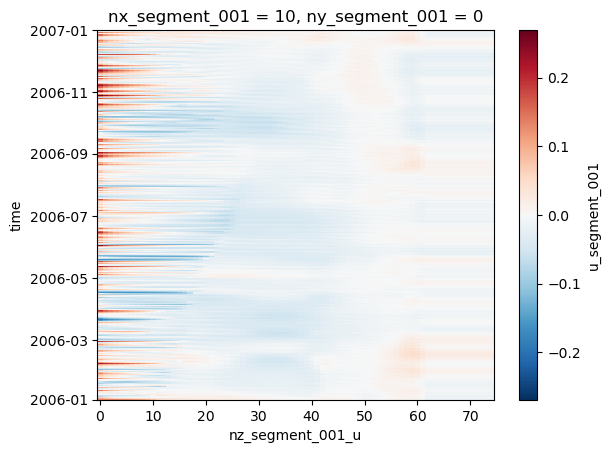

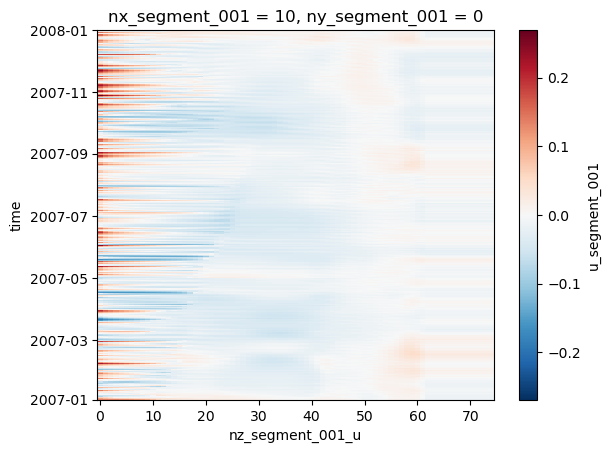

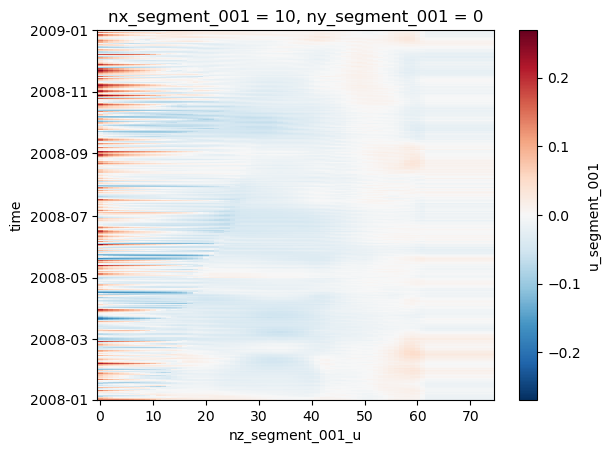

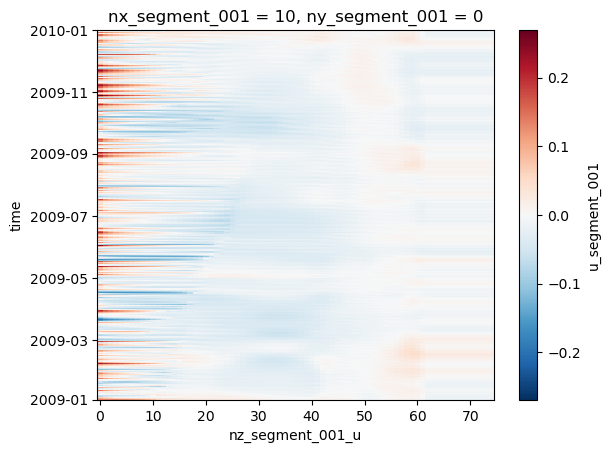

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 2004-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [9]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('2004-12-31','2005-01-01T00:00:00.000000000'))
ds_first


ds_2005 = ds_9091.copy()
ds_2005["time"] = time_greg.sel(time = slice('2005-01-01','2005-12-31'))
ds_2005.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2005 = ds_2005.load()

ds_2006 = ds_9091.copy()
ds_2006["time"] = time_greg.sel(time = slice('2006-01-01','2006-12-31'))
ds_2006.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2006 = ds_2006.load()

ds_2007 = ds_9091.copy()
ds_2007["time"] = time_greg.sel(time = slice('2007-01-01','2007-12-31'))
ds_2007.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2007 = ds_2007.load()

#2008 is  a leap year
ds_2008 = ds_9091_LEAP.copy()
ds_2008["time"] = time_greg.sel(time = slice('2008-01-01','2008-12-31'))
ds_2008.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2008 = ds_2008.load()


ds_2009 = ds_9091.copy()
ds_2009["time"] = time_greg.sel(time = slice('2009-01-01','2009-12-31'))
ds_2009.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2009 = ds_2009.load()



ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('2010-01-01','2010-01-02T00:00:00.000000000'))
ds_last

ds_2000s = xr.combine_by_coords([ds_first,
                                 ds_2005, ds_2006, ds_2007, ds_2008, ds_2009,
                                ds_last])
ds_2000s

#plt.ylim(56,60)

ds_out = ds_2000s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [10]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2005-2009_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2005-2009_forcing_access_yr2_8km_fill.nc

In [ ]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('2009-12-31','2010-01-01T00:00:00.000000000'))
ds_first


ds_2010 = ds_9091.copy()
ds_2010["time"] = time_greg.sel(time = slice('2010-01-01','2010-12-31'))
ds_2010.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2010 = ds_2010.load()

ds_2011 = ds_9091.copy()
ds_2011["time"] = time_greg.sel(time = slice('2011-01-01','2011-12-31'))
ds_2011.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2011 = ds_2011.load()

#2012 is a leap year
ds_2012 = ds_9091_LEAP.copy()
ds_2012["time"] = time_greg.sel(time = slice('2012-01-01','2012-12-31'))
ds_2012.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2012 = ds_2012.load()

ds_2013 = ds_9091.copy()
ds_2013["time"] = time_greg.sel(time = slice('2013-01-01','2013-12-31'))
ds_2013.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2013 = ds_2013.load()


ds_2014 = ds_9091.copy()
ds_2014["time"] = time_greg.sel(time = slice('2014-01-01','2014-12-31'))
ds_2014.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2014 = ds_2014.load()



ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = time_greg.sel(time = slice('2015-01-01','2015-01-02T00:00:00.000000000'))
ds_last

ds_2010s = xr.combine_by_coords([ds_first,
                                 ds_2010, ds_2011, ds_2012, ds_2013, ds_2014,
                                ds_last])
ds_2010s

#plt.ylim(56,60)

ds_out = ds_2010s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [9]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2010-2014_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2010-2014_forcing_access_yr2_8km_fill.nc

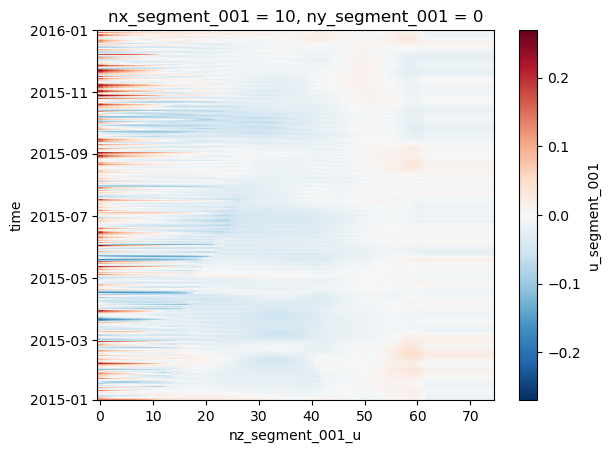

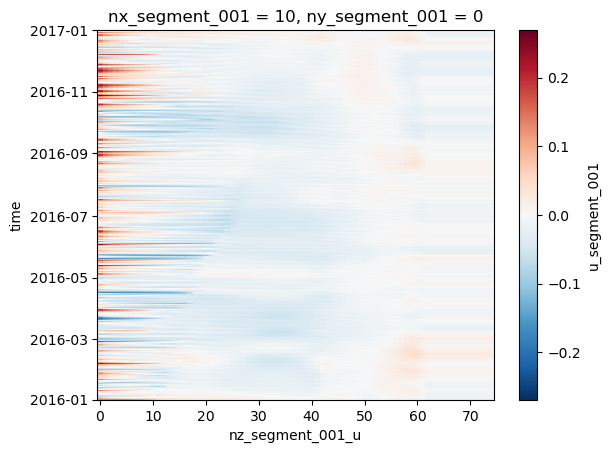

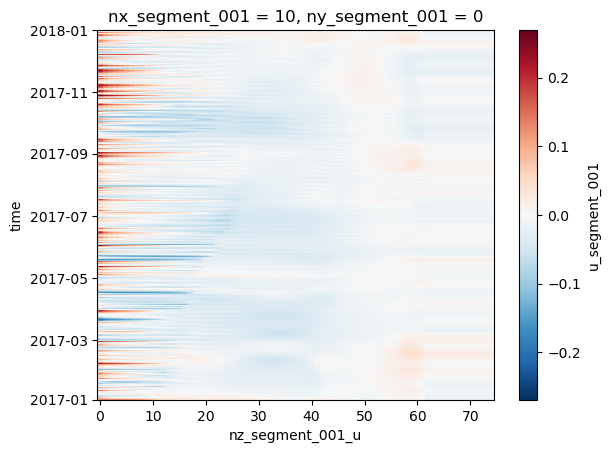

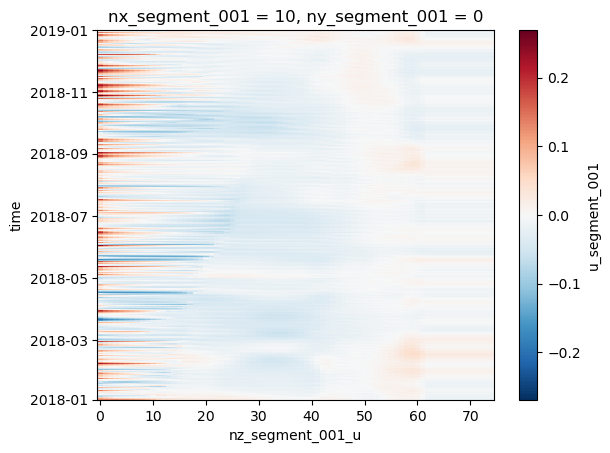

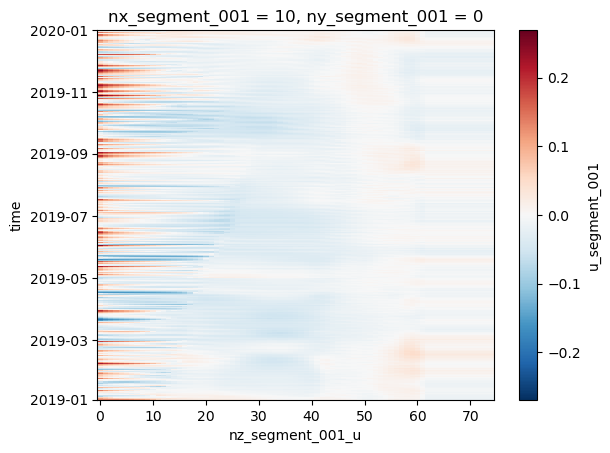

<xarray.Dataset> Size: 76GB
Dimensions:                  (time: 1828, nz_segment_001_pot_temp: 75,
                              ny_segment_001: 1, nx_segment_001: 8641,
                              nz_segment_001_salt: 75, nz_segment_001_u: 75,
                              nz_segment_001_v: 75)
Coordinates:
  * time                     (time) datetime64[ns] 15kB 2014-12-31T12:00:00 ....
  * nz_segment_001_u         (nz_segment_001_u) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_v         (nz_segment_001_v) int32 300B 0 1 2 3 ... 72 73 74
  * nz_segment_001_pot_temp  (nz_segment_001_pot_temp) int32 300B 0 1 ... 73 74
  * nz_segment_001_salt      (nz_segment_001_salt) int32 300B 0 1 2 ... 72 73 74
  * nx_segment_001           (nx_segment_001) int32 35kB 0 1 2 ... 8639 8640
  * ny_segment_001           (ny_segment_001) int32 4B 0
Data variables:
    pot_temp_segment_001     (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    salt_segment_001         (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    eta_t_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    u_segment_001            (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    v_segment_001            (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_u_segment_001         (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_v_segment_001         (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_pot_temp_segment_001  (time, nz_segment_001_pot_temp, ny_segment_001, nx_segment_001) float64 9GB ...
    dz_salt_segment_001      (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float64 9GB ...
    ilist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
    jlist_segment_001        (time, ny_segment_001, nx_segment_001) float64 126MB ...
Attributes:
    description:  Boundary condition at 37.5S generated from https://github.c...

In [13]:

ds_first = ds_9091.copy().isel(time = np.arange(-1,0))
ds_first["time"] = time_greg.sel(time = slice('2014-12-31','2015-01-01T00:00:00.000000000'))
ds_first


ds_2015 = ds_9091.copy()
ds_2015["time"] = time_greg.sel(time = slice('2015-01-01','2015-12-31'))
ds_2015.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2015 = ds_2015.load()

#2016 is a leap year
ds_2016 = ds_9091_LEAP.copy()
ds_2016["time"] = time_greg.sel(time = slice('2016-01-01','2016-12-31'))
ds_2016.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2016 = ds_2016.load()

ds_2017 = ds_9091.copy()
ds_2017["time"] = time_greg.sel(time = slice('2017-01-01','2017-12-31'))
ds_2017.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2017 = ds_2017.load()

ds_2018 = ds_9091.copy()
ds_2018["time"] = time_greg.sel(time = slice('2018-01-01','2018-12-31'))
ds_2018.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2018 = ds_2018.load()


ds_2019 = ds_9091.copy()
ds_2019["time"] = time_greg.sel(time = slice('2019-01-01','2019-12-31'))
ds_2019.u_segment_001.isel(nx_segment_001 = 10).plot()
plt.show()
ds_2019 = ds_2019.load()



ds_last = ds_9091.copy().isel(time = np.arange(1))
ds_last["time"] = np.array(['2020-01-01T12:00:00.000000000'],
      dtype='datetime64[ns]')
ds_last

ds_2010s = xr.combine_by_coords([ds_first,
                                 ds_2015, ds_2016, ds_2017, ds_2018, ds_2019,
                                ds_last])
ds_2010s

#plt.ylim(56,60)

ds_out = ds_2010s.copy()
# make doubles:
ds_out['pot_temp_segment_001'] = ds_out['pot_temp_segment_001'].astype('double') #- 273.15 # Celsius
ds_out['salt_segment_001'] = ds_out['salt_segment_001'].astype('double')
ds_out['eta_t_segment_001'] = ds_out['eta_t_segment_001'].astype('double')
ds_out['u_segment_001'] = ds_out['u_segment_001'].astype('double')
ds_out['v_segment_001'] = ds_out['v_segment_001'].astype('double')
ds_out['dz_u_segment_001'] = ds_out['dz_u_segment_001'].astype('double')
ds_out['dz_v_segment_001'] = ds_out['dz_v_segment_001'].astype('double')
ds_out['dz_pot_temp_segment_001'] = ds_out['dz_pot_temp_segment_001'].astype('double')
ds_out['dz_salt_segment_001'] = ds_out['dz_salt_segment_001'].astype('double')

encoding_dict = {"pot_temp_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "salt_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "u_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                "v_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                 "eta_t_segment_001": {"_FillValue": netCDF4.default_fillvals["f8"],},
                }
ds_out.attrs = {'description': 'Boundary condition at 37.5S generated from https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km.ipynb using ACCESS-OM2-01 daily data from second year after spin-up from WOA13. Potential temperature and practical salinity are used. Then interpolated to IAF Gregorian time using https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-obcs/ACCESS-OM2_panan_boundary_forcing_8km_for_IAF.ipynb'}

ds_out


In [14]:
ds_out.to_netcdf("/g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2015-2019_forcing_access_yr2_8km_fill.nc", encoding=encoding_dict, unlimited_dims="time")


```
ncatted -a axis,nx_segment_001,c,c,x -a axis,ny_segment_001,c,c,y -O /g/data/x77/cy8964/mom6/input/input-8km/ryf_gregorian_2015-2019_forcing_access_yr2_8km_fill.nc